In [ ]:
# !pip install pyarrow

In [ ]:
import pandas as pd

df = pd.read_parquet('salex_failed.parquet')
df.to_csv('salex_failed.csv', index=False)

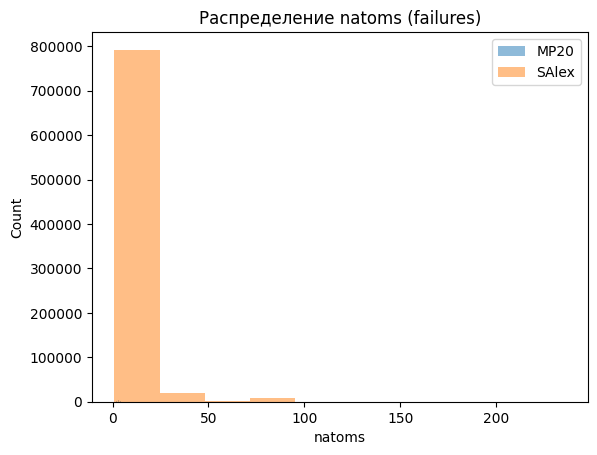

KeyError: 'space_group'

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
for ds in df['dataset'].unique():
    plt.hist(df[df['dataset']==ds]['natoms'], alpha=0.5, label=ds)
plt.xlabel('natoms')
plt.ylabel('Count')
plt.title('Распределение natoms (failures)')
plt.legend()
plt.show()

plt.figure()
for ds in df['dataset'].unique():
    plt.hist(df[df['dataset']==ds]['nedges'], alpha=0.5, label=ds)
plt.xlabel('nedges')
plt.ylabel('Count')
plt.title('Распределение nedges (failures)')
plt.legend()
plt.show()

plt.figure()
top_sg = df['space_group'].value_counts().nlargest(10)
plt.bar(top_sg.index.astype(str), top_sg.values)
plt.xticks(rotation=45)
plt.xlabel('Space Group')
plt.ylabel('Count')
plt.title('Топ-10 групп симметрии (failures)')
plt.show()

plt.figure()
for ds in df['dataset'].unique():
    plt.hist(df[df['dataset']==ds]['num_unique_elements'], alpha=0.5, label=ds)
plt.xlabel('num_unique_elements')
plt.ylabel('Count')
plt.title('Уникальные элементы (failures)')
plt.legend()
plt.show()

plt.figure()
for ds in df['dataset'].unique():
    subset = df[df['dataset']==ds]
    plt.scatter(subset['natoms'], subset['nedges'], alpha=0.5, label=ds)
plt.xlabel('natoms')
plt.ylabel('nedges')
plt.title('natoms vs nedges (failures)')
plt.legend()
plt.show()


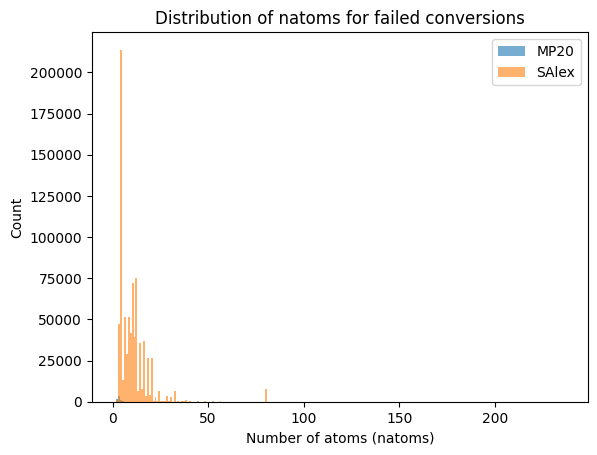

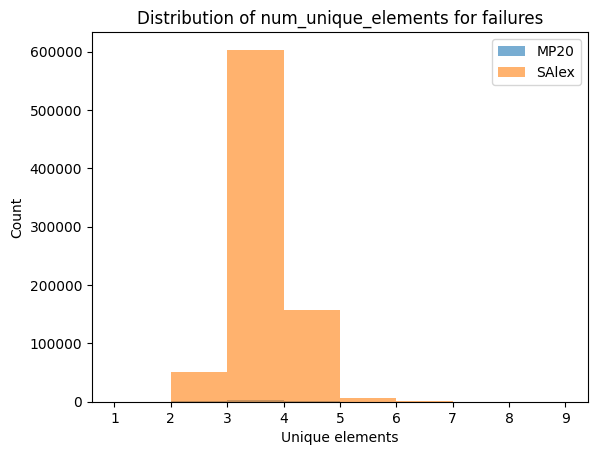

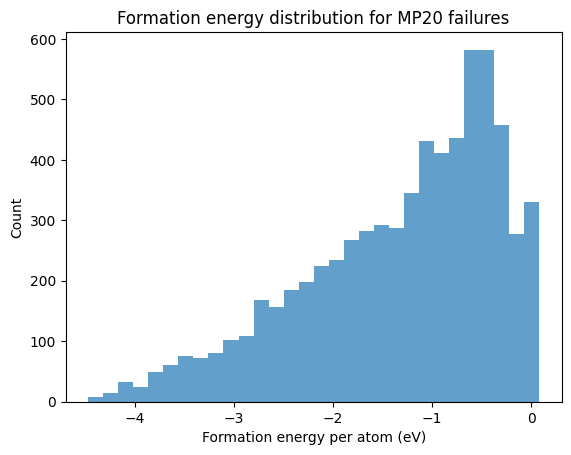

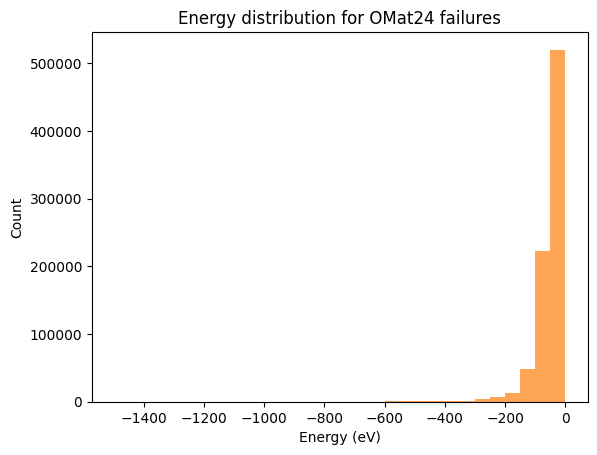

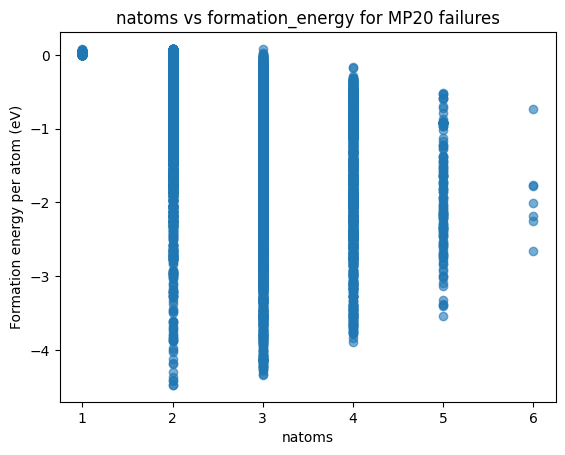

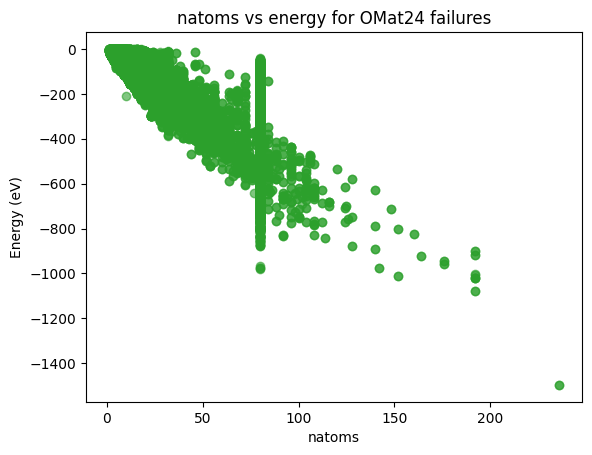

In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

mp['natoms'] = mp['elements'].apply(lambda s: len(ast.literal_eval(s)) if pd.notna(s) else None)

def count_unique(row):
    if row['dataset'] == 'MP20':
        elems = ast.literal_eval(row['elements'])
        return len(set(elems))
    else:
        nums = row['atomic_numbers'].strip('[]').split()
        return len(set(nums))
mp['num_unique_elements'] = mp.apply(count_unique, axis=1)
sa['num_unique_elements'] = sa.apply(count_unique, axis=1)

common = ['dataset', 'natoms', 'num_unique_elements']
df = pd.concat([mp[common], sa[common]], ignore_index=True)

plt.figure()
for ds in df['dataset'].unique():
    plt.hist(df[df['dataset']==ds]['natoms'].dropna(), bins=range(1, df['natoms'].max()+2), alpha=0.6, label=ds)
plt.xlabel('Number of atoms (natoms)')
plt.ylabel('Count')
plt.title('Distribution of natoms for failed conversions')
plt.legend()
plt.show()

plt.figure()
for ds in df['dataset'].unique():
    plt.hist(df[df['dataset']==ds]['num_unique_elements'], bins=range(1, df['num_unique_elements'].max()+2), alpha=0.6, label=ds)
plt.xlabel('Unique elements')
plt.ylabel('Count')
plt.title('Distribution of num_unique_elements for failures')
plt.legend()
plt.show()

plt.figure()
plt.hist(mp['formation_energy_per_atom'].dropna(), bins=30, alpha=0.7, color='C0')
plt.xlabel('Formation energy per atom (eV)')
plt.ylabel('Count')
plt.title('Formation energy distribution for MP20 failures')
plt.show()

plt.figure()
plt.hist(sa['energy'].dropna(), bins=30, alpha=0.7, color='C1')
plt.xlabel('Energy (eV)')
plt.ylabel('Count')
plt.title('Energy distribution for OMat24 failures')
plt.show()

plt.figure()
plt.scatter(mp['natoms'], mp['formation_energy_per_atom'], alpha=0.6)
plt.xlabel('natoms')
plt.ylabel('Formation energy per atom (eV)')
plt.title('natoms vs formation_energy for MP20 failures')
plt.show()

plt.figure()
plt.scatter(sa['natoms'], sa['energy'], alpha=0.6, color='C2')
plt.xlabel('natoms')
plt.ylabel('Energy (eV)')
plt.title('natoms vs energy for OMat24 failures')
plt.show()

In [10]:
mp.head()

,Unnamed: 0,status,material_id,time,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,dataset,num_unique_elements
0,0,E,mp-10018,0.123928,0.020409,0.0000,Ac,0.020409,['Ac'],# generated using pymatgen\ndata_Ac\n_symmetry...,225,MP20,1
1,1,E,mp-1211359,5.697293,-2.457178,1.6187,LaMn3Cr4O12,0.041672,"['Cr', 'La', 'Mn', 'O']",# generated using pymatgen\ndata_LaMn3Cr4O12\n...,204,MP20,4
2,2,E,mp-38816,0.633848,-1.634741,0.0000,Mg(TiS2)4,0.031401,"['Mg', 'S', 'Ti']",# generated using pymatgen\ndata_Mg(TiS2)4\n_s...,166,MP20,3
3,3,E,mp-4195,0.241615,-0.665822,0.0000,Tm(NiGe)2,0.000000,"['Tm', 'Ni', 'Ge']",# generated using pymatgen\ndata_Tm(NiGe)2\n_s...,139,MP20,3
4,4,E,mp-1102240,1.459751,-4.167986,6.3522,SrF2,0.064573,"['F', 'Sr']",# generated using pymatgen\ndata_SrF2\n_symmet...,62,MP20,2


In [ ]:
import pandas as pd
import ast

def mp20_natoms(row):
    if pd.notna(row['elements']):
        elems = ast.literal_eval(row['elements'])
        return len(elems)
    return None

mp['natoms'] = mp.apply(mp20_natoms, axis=1)

def count_unique(row):
    if row['dataset']=='MP20':
        elems = ast.literal_eval(row['elements'])
        return len(set(elems))
    else:
        nums = row['atomic_numbers'].strip('[]').split()
        return len(set(nums))

mp['num_unique_elements'] = mp.apply(count_unique, axis=1)
sa['num_unique_elements'] = sa.apply(count_unique, axis=1)

common = ['dataset', 'natoms', 'num_unique_elements']
df = pd.concat([mp[common], sa[common]], ignore_index=True)

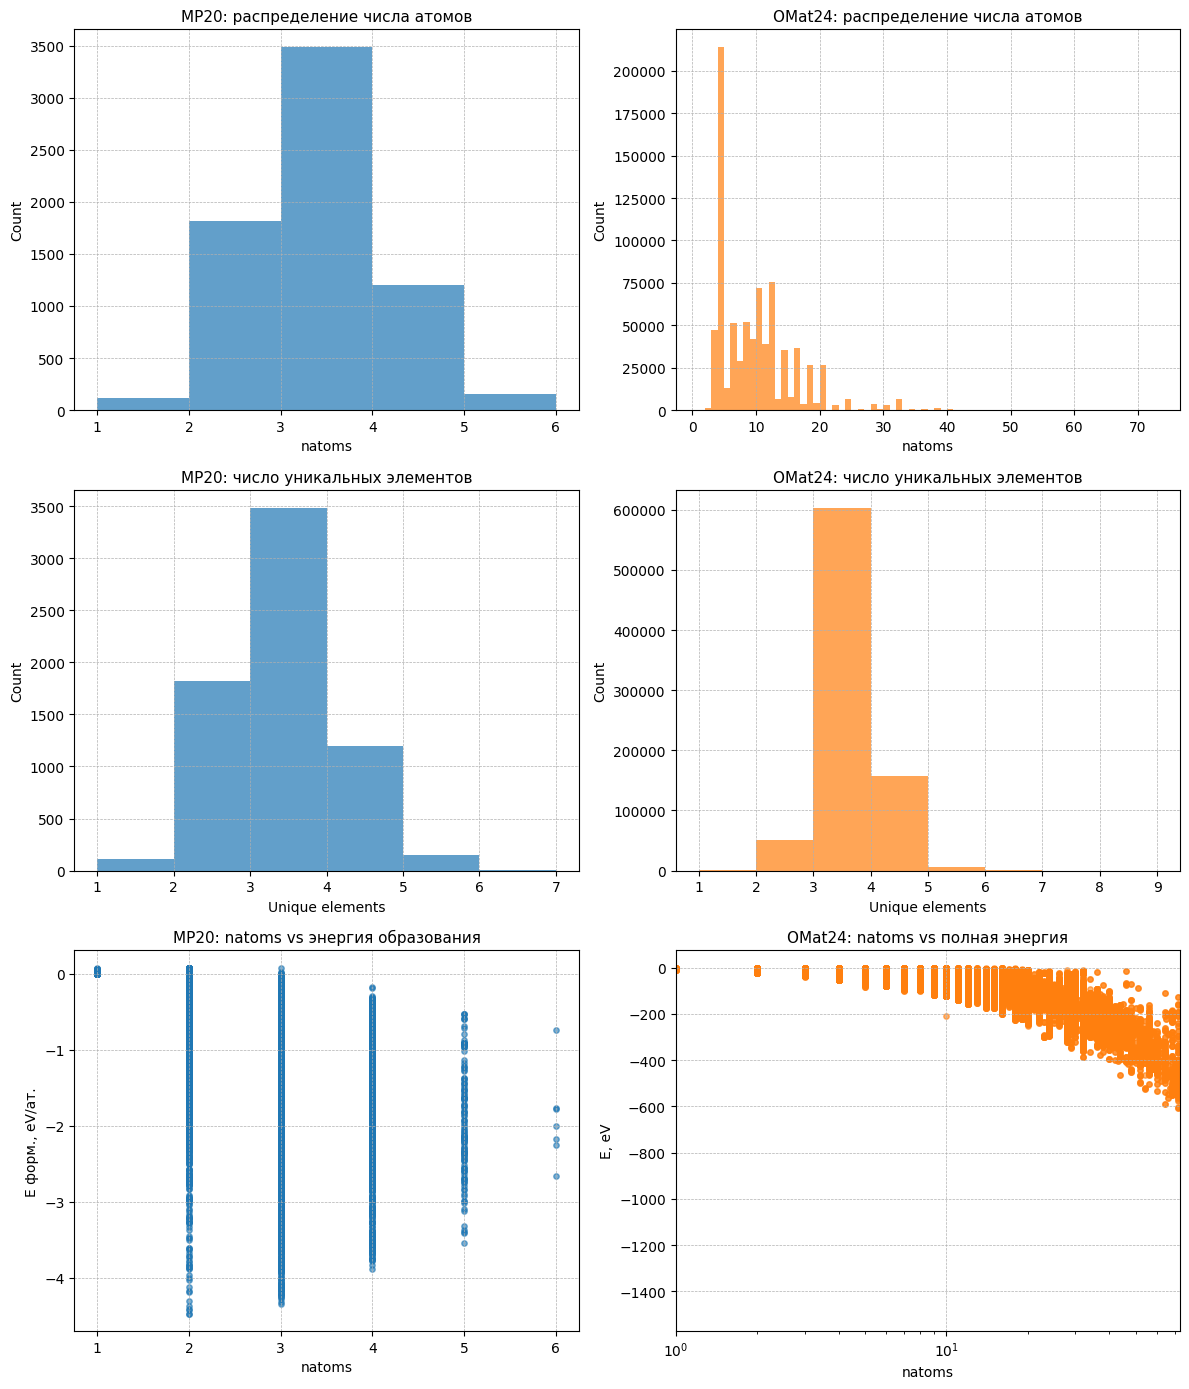

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

axes[0,0].hist(mp['natoms'], 
               bins=range(1, int(mp['natoms'].quantile(0.99)) + 2), 
               color='C0', alpha=0.7)
axes[0,1].hist(sa['natoms'], 
               bins=range(1, int(sa['natoms'].quantile(0.99)) + 2), 
               color='C1', alpha=0.7)

axes[1,0].hist(mp['num_unique_elements'], 
               bins=range(1, mp['num_unique_elements'].max() + 2), 
               color='C0', alpha=0.7)
axes[1,1].hist(sa['num_unique_elements'], 
               bins=range(1, sa['num_unique_elements'].max() + 2), 
               color='C1', alpha=0.7)

axes[2,0].scatter(mp['natoms'], mp['formation_energy_per_atom'],
                  c='C0', alpha=0.6, s=15)
axes[2,1].scatter(sa['natoms'], sa['energy'],
                  c='C1', alpha=0.6, s=15)

for ax, (title, xlabel, ylabel) in zip(
    axes.flatten(),
    [
        ('MP20: распределение числа атомов',    'natoms', 'Count'),
        ('OMat24: распределение числа атомов',  'natoms', 'Count'),
        ('MP20: число уникальных элементов',    'Unique elements', 'Count'),
        ('OMat24: число уникальных элементов',  'Unique elements', 'Count'),
        ('MP20: natoms vs энергия образования', 'natoms', 'E форм., eV/ат.'),
        ('OMat24: natoms vs полная энергия',    'natoms', 'E, eV'),
    ]
):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', lw=0.5)
axes[2,1].set_xscale('log')
axes[2,1].set_xlim(1, sa['natoms'].quantile(0.99) + 1)

plt.tight_layout()
plt.show()